## 👤 Author
### Himanshi Tiwari

## 📌 Project Title

### Social Network Ads Prediction using Logistic Regression

## 📖 Introduction
#### This project focuses on predicting whether a user will purchase a product based on social network advertisement data. The dataset contains user information such as age, estimated salary, and purchase behavior. A machine learning classification model is used to analyze patterns and make predictions.¶

## 🎯 Objective
####  To build a classification model using Logistic Regression
#### To predict whether a user will purchase a product
#### To understand the relationship between age, salary, and buying behavior
#### To evaluate model performance using accuracy

## ⚙️ Steps Performed
#### 1.Import Libraries
#### 2.Load Dataset
#### 3.Basic Understanding
#### 4.Data Cleaning
#### 5.Data Preprocessing
#### 6.Feature Selection
#### 7.Divide into classes using LDA
#### 8.Train-Test Split
#### 9.Handle Imbalanced Dataset¶
#### 10.Model Building(Logistic Regression)
#### 11.Model Training
#### 12.Make Prediction
#### 13.Model Evaluation
#### 14.Make Prediction(New Data)
#### 15. ROC Curve Analysis


### Step-1 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

### Step-2 Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\abhit\Downloads\logistic regression dataset-Social_Network_Ads.csv")

In [3]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


### Step-3 Basic Understanding

In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [6]:
df.shape

(400, 5)

In [7]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


### Step-4 Data Cleaning

In [9]:
df.drop(['User ID'] , axis=1, inplace=True)

### Step-5 Data Preprocessing

In [10]:
## check missing values
df.isnull().sum()

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

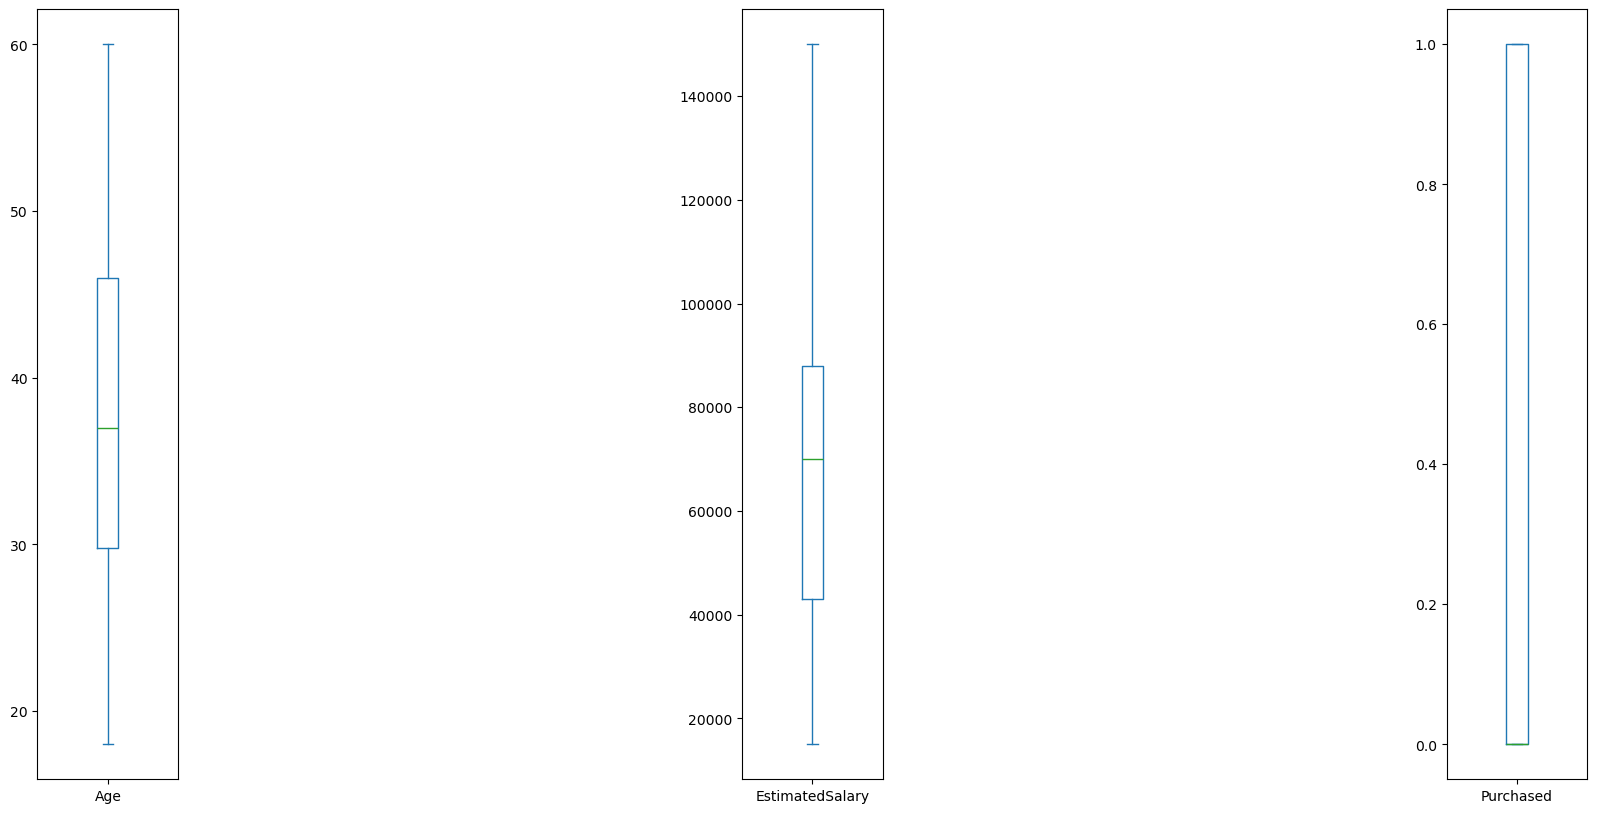

In [11]:
## check outlier
# boxplot
df.plot(kind="box",subplots=True,sharey=False,figsize=(20,10))
plt.subplots_adjust(wspace=4)
plt.show()

In [12]:
## label encoding
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0
...,...,...,...,...
395,0,46,41000,1
396,1,51,23000,1
397,0,50,20000,1
398,1,36,33000,0


### Step-6 Feature Selection

In [13]:
## target variavle
df.value_counts(df['Purchased'])

Purchased
0    257
1    143
Name: count, dtype: int64

In [14]:
print((df['Purchased'].value_counts(normalize=True) * 100).round(2))

Purchased
0    64.25
1    35.75
Name: proportion, dtype: float64


In [15]:
##split data into x and y
X = df.drop('Purchased', axis =1)
y = df['Purchased']

In [16]:
X

,Gender,Age,EstimatedSalary
0,1,19,19000
1,1,35,20000
2,0,26,43000
3,0,27,57000
4,1,19,76000
...,...,...,...
395,0,46,41000
396,1,51,23000
397,0,50,20000
398,1,36,33000


In [17]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

### Step-7 Divide into Classes using LDA¶

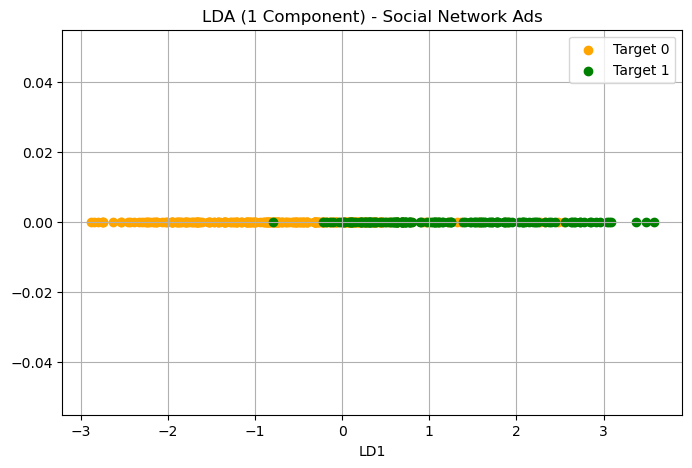

In [18]:
## perform LDA
lda = LinearDiscriminantAnalysis(n_components=1)
lda_X = lda.fit(X, y).transform(X)

plt.figure(figsize=(8,5))

# Plot using 1D (use zeros for y-axis just for visualization)
plt.scatter(lda_X[y == 0, 0],
            [0]*sum(y == 0),
            c='orange', label='Target 0')

plt.scatter(lda_X[y == 1, 0],
            [0]*sum(y == 1),
            c='green', label='Target 1')

plt.xlabel('LD1')
plt.title('LDA (1 Component) - Social Network Ads')
plt.legend()
plt.grid()
plt.show()

### Step-8 Train-Test Split

In [19]:
## split train and test
x_train, x_test, y_train, y_test = train_test_split( X,y, test_size=0.2, random_state=42)

In [20]:
## standarization
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Step-9 Handle Imbalanced Dataset

In [21]:
## using smote balanced data

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [22]:
df_balanced =  pd.Series(y_resampled).value_counts()

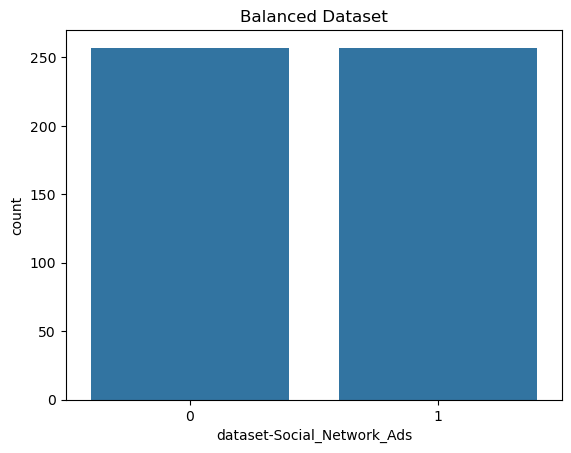

In [23]:
df_balanced = pd.DataFrame({
    "dataset-Social_Network_Ads": y_resampled
})

sns.countplot(x="dataset-Social_Network_Ads", data=df_balanced)

plt.title("Balanced Dataset")
plt.show()

### Step-10 Model Building (Logistic Regression)

In [24]:
model = LogisticRegression(max_iter=1000)

### Step-11 Model Training

In [25]:
model.fit(X_resampled, y_resampled )

LogisticRegression(max_iter=1000)

### Step-12 Make prediction

In [26]:
## prediction on test data
y_pred = model.predict(x_test)

### Step-13 Model Evaluation

In [27]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[47  5]
 [ 3 25]]


In [28]:

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92        52
           1       0.83      0.89      0.86        28

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



### Step-14 Make Prediction¶(New Data)

In [29]:
model.predict([[0,25,4400]])

array([0], dtype=int64)

In [30]:
model.predict([[0,46,41000]])

array([1], dtype=int64)

In [31]:
model.predict([[1,37,96000]])

array([1], dtype=int64)

In [32]:
model.predict([[0,35,40000]])

array([0], dtype=int64)

### Step-15 ROC Curve Analysis

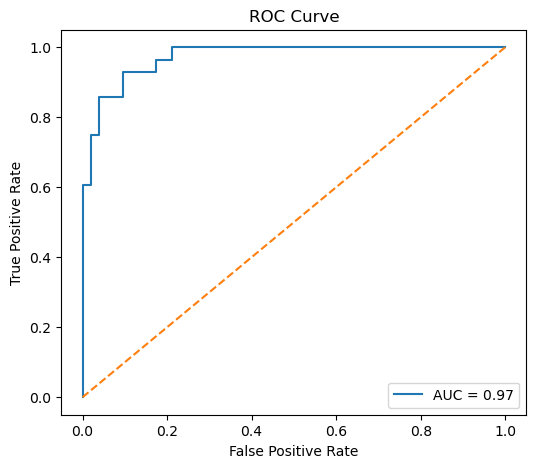

In [33]:
## ROC curve
y_prob = model.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()